# Pipeline Evaluation Analytics

This notebook analyzes `pipeline_eval_summary.csv` with **SNR as the main metric**.

Primary goals:
- evaluate overall pipeline performance,
- inspect SNR distribution and outliers,
- analyze runtime vs SNR trade-offs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


In [2]:
# Resolve CSV path whether notebook is run from repo root or from this folder.
candidate_paths = [
    Path("pipeline_eval_summary.csv"),
    Path("data/output/evaluation/pipeline_eval_summary.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Could not locate pipeline_eval_summary.csv")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Rows: {len(df)}")
df.head(3)

Loaded: pipeline_eval_summary.csv
Rows: 31


,recording,input_path,error,time_load_s,sample_rate_hz,duration_s,num_samples,window_L,time_hankel_s,svd_device,time_svd_s,k_rank,num_singular_values,time_reconstruct_s,output_wav,time_save_audio_s,energy_threshold,kept_sv_energy_pct,rms_amplitude_kept_pct,removed_signal_energy_pct,snr_kept_vs_removed_db,spectral_centroid_original_hz,spectral_centroid_denoised_hz,spectral_centroid_shift_hz,time_total_s
0,_test_tone,/Users/yaremakertytsky/Documents/Studying/seme...,NaN,0.566472,16000,0.200000,3200,800,0.000040,cpu,0.846951,2,800,0.003918,/Users/yaremakertytsky/Documents/Studying/seme...,0.000703,0.95,99.999994,99.999997,0.000006,72.064305,440.000011,440.000000,-0.000011,1.418337
1,recording_011_female,/Users/yaremakertytsky/Documents/Studying/seme...,NaN,0.001152,16000,5.107938,81727,1600,0.000035,cpu,20.041109,223,1600,0.160384,/Users/yaremakertytsky/Documents/Studying/seme...,0.002263,0.95,95.054257,97.213092,4.390851,13.329009,531.541975,463.599162,-67.942814,20.216633
2,recording_011_male,/Users/yaremakertytsky/Documents/Studying/seme...,NaN,0.001301,16000,6.538188,104611,1600,0.000019,cpu,29.164223,198,1600,0.226578,/Users/yaremakertytsky/Documents/Studying/seme...,0.001928,0.95,95.035546,97.266905,4.535245,13.193294,429.016880,338.756191,-90.260689,29.409542


In [3]:
numeric_cols = [
    "time_load_s", "sample_rate_hz", "duration_s", "num_samples", "window_L",
    "time_hankel_s", "time_svd_s", "k_rank", "num_singular_values",
    "time_reconstruct_s", "time_save_audio_s", "energy_threshold",
    "kept_sv_energy_pct", "rms_amplitude_kept_pct", "removed_signal_energy_pct",
    "snr_kept_vs_removed_db", "spectral_centroid_original_hz",
    "spectral_centroid_denoised_hz", "spectral_centroid_shift_hz", "time_total_s",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["has_error"] = df["error"].notna() if "error" in df.columns else False
df["speaker"] = np.where(df["recording"].str.contains("female", na=False), "female", np.where(df["recording"].str.contains("male", na=False), "male", "unknown"))
df["is_test_tone"] = df["recording"].eq("_test_tone")

ok = df[~df["has_error"]].copy()
print(f"Successful rows: {len(ok)} / {len(df)}")
ok.describe(include="all").T

Successful rows: 31 / 31


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording,31,31,_test_tone,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
input_path,31,31,/Users/yaremakertytsky/Documents/Studying/seme...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
error,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_load_s,31.0,NaN,NaN,NaN,0.019291,0.101553,0.000821,0.000906,0.001006,0.001119,0.566472
sample_rate_hz,31.0,NaN,NaN,NaN,16000.0,0.0,16000.0,16000.0,16000.0,16000.0,16000.0
duration_s,31.0,NaN,NaN,NaN,2.644446,1.13612,0.2,2.210844,2.617188,2.820969,6.538188
num_samples,31.0,NaN,NaN,NaN,42311.129032,18177.927599,3200.0,35373.5,41875.0,45135.5,104611.0
window_L,31.0,NaN,NaN,NaN,1574.193548,143.684242,800.0,1600.0,1600.0,1600.0,1600.0
time_hankel_s,31.0,NaN,NaN,NaN,0.000025,0.000012,0.000015,0.000018,0.000021,0.000028,0.000068
svd_device,31,1,cpu,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
main = ok[~ok["is_test_tone"]].copy()

kpis = {
    "num_files": int(len(df)),
    "num_success": int((~df["has_error"]).sum()),
    "num_failed": int(df["has_error"].sum()),
    "avg_total_time_s": float(main["time_total_s"].mean()),
    "p95_total_time_s": float(main["time_total_s"].quantile(0.95)),
    "avg_svd_time_s": float(main["time_svd_s"].mean()),
    "avg_snr_db": float(main["snr_kept_vs_removed_db"].mean()),
    "median_snr_db": float(main["snr_kept_vs_removed_db"].median()),
    "p10_snr_db": float(main["snr_kept_vs_removed_db"].quantile(0.10)),
    "p90_snr_db": float(main["snr_kept_vs_removed_db"].quantile(0.90)),
    "avg_kept_sv_energy_pct": float(main["kept_sv_energy_pct"].mean()),
    "avg_centroid_shift_hz": float(main["spectral_centroid_shift_hz"].mean()),
}

pd.Series(kpis, name="value")

num_files                 31.000000
num_success               31.000000
num_failed                 0.000000
avg_total_time_s          10.526557
p95_total_time_s          20.185038
avg_svd_time_s            10.430197
avg_snr_db                13.233708
median_snr_db             13.197656
p10_snr_db                13.023420
p90_snr_db                13.429157
avg_kept_sv_energy_pct    95.027028
avg_centroid_shift_hz    -86.558593
Name: value, dtype: float64

In [9]:
print("Top 10 lowest SNR (main metric):")
display(main.sort_values("snr_kept_vs_removed_db", ascending=True)[["recording", "snr_kept_vs_removed_db", "kept_sv_energy_pct", "time_total_s", "spectral_centroid_shift_hz"]].head(10))

print("Top 10 highest SNR:")
display(main.sort_values("snr_kept_vs_removed_db", ascending=False)[["recording", "snr_kept_vs_removed_db", "kept_sv_energy_pct", "time_total_s", "spectral_centroid_shift_hz"]].head(10))

print("Top 10 slowest files:")
display(main.sort_values("time_total_s", ascending=False)[["recording", "duration_s", "time_svd_s", "time_total_s", "snr_kept_vs_removed_db"]].head(10))

Top 10 lowest SNR (main metric):


,recording,snr_kept_vs_removed_db,kept_sv_energy_pct,time_total_s,spectral_centroid_shift_hz
18,recording_167_male,12.936062,95.015251,9.460569,-121.685204
28,recording_360_male,12.965349,95.009566,10.079555,-114.818946
11,recording_089_female,12.984994,95.001294,12.599775,-91.524747
14,recording_151_male,13.027689,95.007924,10.184523,-110.965627
16,recording_158_male,13.029877,95.006740,9.737125,-90.021285
20,recording_195_male,13.047818,95.027691,8.118998,-77.171892
5,recording_031_female,13.072935,95.019137,4.191178,-113.580495
26,recording_244_male,13.087963,95.037196,11.749726,-77.696937
4,recording_012_male,13.108811,95.007146,20.146421,-112.804085
10,recording_079_male,13.132061,95.018853,10.009994,-91.696130


Top 10 highest SNR:


,recording,snr_kept_vs_removed_db,kept_sv_energy_pct,time_total_s,spectral_centroid_shift_hz
24,recording_229_male,14.027957,95.113193,6.168207,-43.468599
15,recording_158_female,13.596868,95.073080,4.511262,-32.601472
19,recording_195_female,13.458453,95.058678,6.351896,-71.373786
23,recording_229_female,13.425902,95.042972,8.152586,-50.248282
21,recording_196_female,13.406319,95.037693,11.356704,-43.889704
30,recording_361_male,13.354405,95.056062,7.191411,-68.356188
22,recording_196_male,13.350213,95.004497,7.645042,-98.875038
27,recording_360_female,13.329660,95.014157,10.632236,-62.215470
1,recording_011_female,13.329009,95.054257,20.216633,-67.942814
17,recording_167_female,13.303327,95.024749,9.852215,-65.842040


Top 10 slowest files:


,recording,duration_s,time_svd_s,time_total_s,snr_kept_vs_removed_db
2,recording_011_male,6.538188,29.164223,29.409542,13.193294
1,recording_011_female,5.107938,20.041109,20.216633,13.329009
4,recording_012_male,4.335687,19.978941,20.146421,13.108811
3,recording_012_female,3.457625,13.926267,14.060322,13.188727
11,recording_089_female,2.889875,12.495962,12.599775,12.984994
26,recording_244_male,3.287313,11.640995,11.749726,13.087963
21,recording_196_female,3.130125,11.247170,11.356704,13.406319
9,recording_079_female,2.821250,11.066827,11.166467,13.245626
8,recording_069_male,2.668875,10.638826,10.746558,13.158596
27,recording_360_female,2.820688,10.526627,10.632236,13.329660


/var/folders/cb/_vkbs15j09d73dptlvj8gn5m0000gn/T/ipykernel_75109/2784648795.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(snr_groups, labels=snr_labels, vert=True)


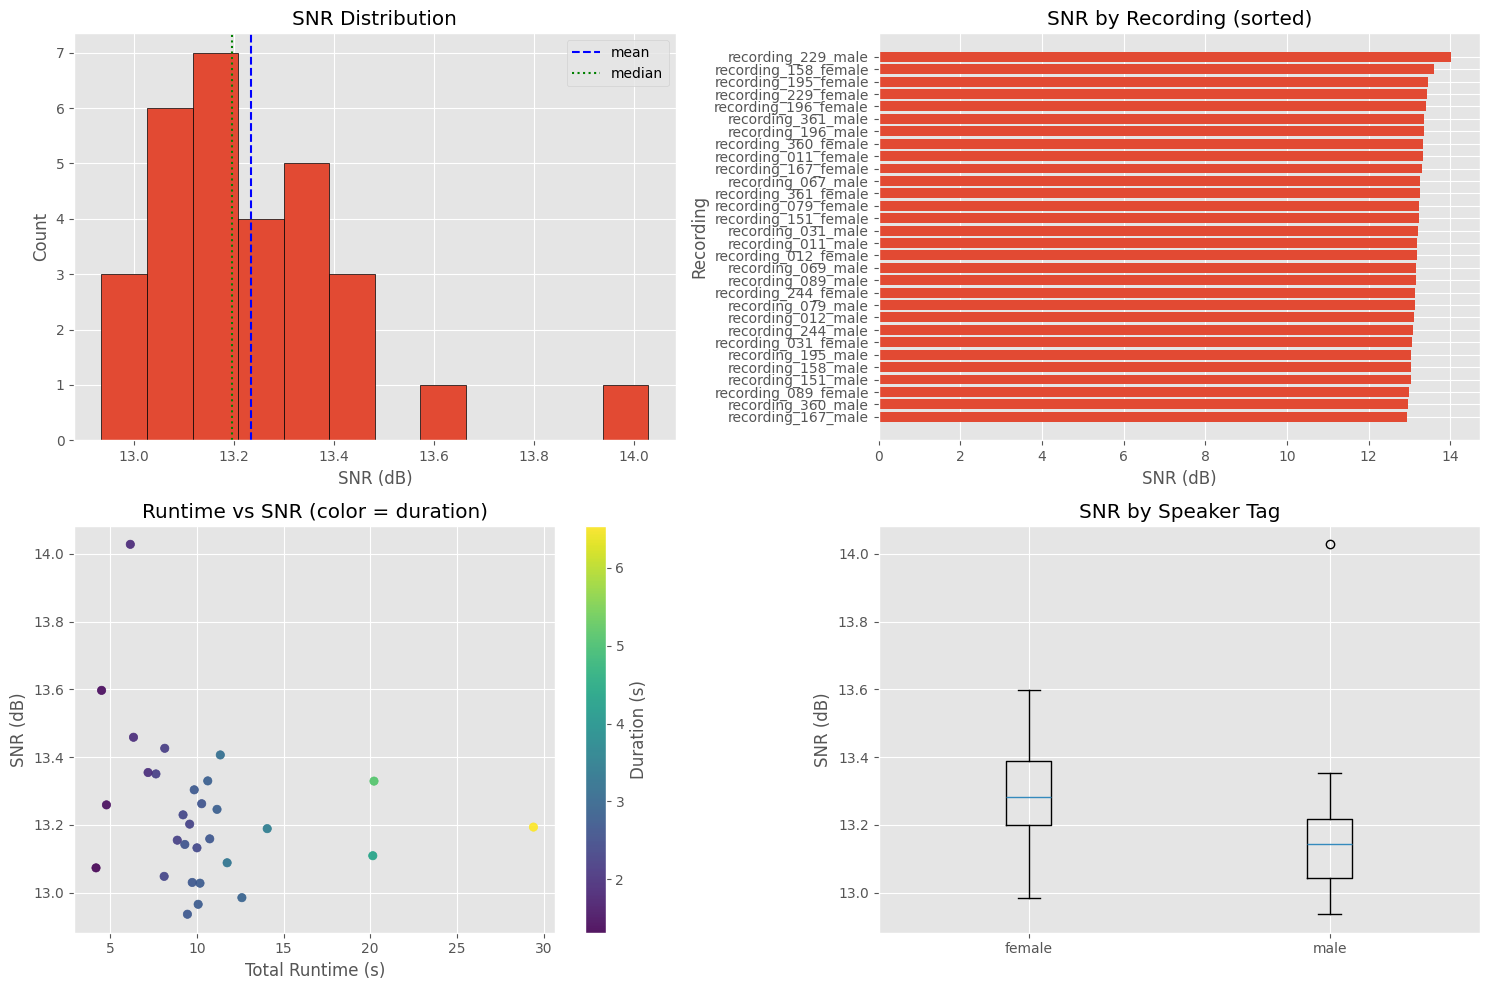

In [10]:
plot_df = main.sort_values("snr_kept_vs_removed_db").copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) SNR distribution (main metric)
axes[0, 0].hist(plot_df["snr_kept_vs_removed_db"].dropna(), bins=12, edgecolor="black")
axes[0, 0].axvline(plot_df["snr_kept_vs_removed_db"].mean(), color="blue", linestyle="--", linewidth=1.5, label="mean")
axes[0, 0].axvline(plot_df["snr_kept_vs_removed_db"].median(), color="green", linestyle=":", linewidth=1.5, label="median")
axes[0, 0].set_title("SNR Distribution")
axes[0, 0].set_xlabel("SNR (dB)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# 2) SNR ranking by recording
axes[0, 1].barh(plot_df["recording"], plot_df["snr_kept_vs_removed_db"])
axes[0, 1].set_title("SNR by Recording (sorted)")
axes[0, 1].set_xlabel("SNR (dB)")
axes[0, 1].set_ylabel("Recording")

# 3) Runtime vs SNR (trade-off)
scatter = axes[1, 0].scatter(
    plot_df["time_total_s"],
    plot_df["snr_kept_vs_removed_db"],
    c=plot_df["duration_s"],
    cmap="viridis",
    alpha=0.9,
)
axes[1, 0].set_title("Runtime vs SNR (color = duration)")
axes[1, 0].set_xlabel("Total Runtime (s)")
axes[1, 0].set_ylabel("SNR (dB)")
fig.colorbar(scatter, ax=axes[1, 0], label="Duration (s)")

# 4) SNR by speaker tag
snr_groups = [g["snr_kept_vs_removed_db"].dropna().values for _, g in plot_df.groupby("speaker")]
snr_labels = [name for name, _ in plot_df.groupby("speaker")]
if snr_groups:
    axes[1, 1].boxplot(snr_groups, labels=snr_labels, vert=True)
axes[1, 1].set_title("SNR by Speaker Tag")
axes[1, 1].set_ylabel("SNR (dB)")

plt.tight_layout()
plt.show()

In [11]:
corr_cols = [
    "duration_s", "window_L", "k_rank", "time_svd_s", "time_reconstruct_s", "time_total_s",
    "kept_sv_energy_pct", "snr_kept_vs_removed_db", "spectral_centroid_shift_hz",
]
corr_cols = [c for c in corr_cols if c in ok.columns]

corr = ok[corr_cols].corr(numeric_only=True)
display(corr.style.background_gradient(cmap="coolwarm", axis=None))

,duration_s,window_L,k_rank,time_svd_s,time_reconstruct_s,time_total_s,kept_sv_energy_pct,snr_kept_vs_removed_db,spectral_centroid_shift_hz
duration_s,1.000000,0.399315,0.326630,0.985955,0.965979,0.984358,-0.400722,-0.403129,-0.229701
window_L,0.399315,1.000000,0.508775,0.328111,0.370953,0.311217,-0.999628,-0.999795,-0.464468
k_rank,0.326630,0.508775,1.000000,0.331412,0.494123,0.324949,-0.520519,-0.512951,-0.609670
time_svd_s,0.985955,0.328111,0.331412,1.000000,0.977441,0.999840,-0.330528,-0.332373,-0.246219
time_reconstruct_s,0.965979,0.370953,0.494123,0.977441,1.000000,0.976659,-0.375422,-0.375482,-0.320897
time_total_s,0.984358,0.311217,0.324949,0.999840,0.976659,1.000000,-0.313671,-0.315511,-0.239340
kept_sv_energy_pct,-0.400722,-0.999628,-0.520519,-0.330528,-0.375422,-0.313671,1.000000,0.999873,0.478697
snr_kept_vs_removed_db,-0.403129,-0.999795,-0.512951,-0.332373,-0.375482,-0.315511,0.999873,1.000000,0.475524
spectral_centroid_shift_hz,-0.229701,-0.464468,-0.609670,-0.246219,-0.320897,-0.239340,0.478697,0.475524,1.000000


## Notes / Interpretation

- Treat `snr_kept_vs_removed_db` as the primary score for denoising quality.
- Use the SNR ranking chart to quickly identify weak recordings for manual listening checks.
- Use the runtime-vs-SNR chart to evaluate performance/quality trade-offs.
- For robust benchmarking, run multiple repeats and compare `mean`, `std`, and `p95` SNR per recording.